Description
-----------
This code simulates the diffusion of charge carriers (holes) generated at
different interaction depths inside a detector.

For each initial depth:

    - N_charges charge carriers are generated.
    - Each carrier performs a 3D random walk according to the diffusion
      coefficient.
    - At every time step the carrier may:
          - be trapped by Li precipitates,
          - reach the n+ contact,
          - be collected at the FCCD.
    - The collection efficiency (CCE) and the drift-time distributions are
      recorded.

At the end the code computes:

    - Charge Collection Efficiency (CCE);
    - t10 and t90 drift times;
    - time spread (t90 − t10);
    - histograms of the arrival-time distributions.



# Packets

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc
from tqdm import tqdm
import threading
from matplotlib.cm import get_cmap

In [19]:
# ============================================================
# GEOEMTRY(cm)
# ============================================================
Lx = 0.2
Ly = 0.2
Lz = 0.2

dx = 0.001
FCCD_cm = 0.1
x_RDR = 0.025 #cm

# ============================================================
# PHYSICS PARAMETERS
# ============================================================
alpha_global = 2e-10

t_ann = 2 * 60 * 60
T_ann = 473

R = 1.98
H = 11800
D0 = 2.5e-3

Ns = 10 ** (21.27 - 2610 / T_ann)
#D_Li = D0 * np.exp(-H / (R * T_ann))
D_Li = 7.66e-9 #cm-2 s

D = 28.9
dt = 1.0
Nt = 40000
T_diff = 90

r_Li = 0.002

In [20]:
# ============================================================
# COSTANTS
# ============================================================
m0 = 9.11e-31
m_eff = 0.21 * m0
kB = 1.38e-23

v_th = np.sqrt(3 * kB * T_diff / m_eff) * 100
sigma_trap = np.pi * r_Li ** 2

pref_tau = 1.0 / (v_th * sigma_trap)

step_sigma = np.sqrt(2 * D * dt) * 1e-4

In [21]:
# ============================================================
# LOOKUP TABLE τ(x)
# ============================================================
LUT_dx = step_sigma / 0.1
xgrid = np.arange(0, FCCD_cm + LUT_dx, LUT_dx)

In [22]:
def tau_exact(x, alpha):
    Nd_saturation= 1e14
    Nd = Ns * erfc(x / (2 * np.sqrt(D_Li * t_ann)))
    return pref_tau / (alpha * ( Nd - Nd_saturation ) ) if alpha != 0 else np.inf

taugrid = np.array([tau_exact(x, alpha_global) for x in xgrid])

step = 0.01

In [23]:
# ============================================================
# τ(x) via lookup
# ============================================================
def tau_hole(x):
    idx = int(np.clip(np.floor(x / LUT_dx), 0, len(taugrid) - 1))
    return taugrid[idx]


In [24]:

# ============================================================
# trapping probability
# ============================================================
def trapping_probability(x):
    if alpha_global == 0.0:
        return 0.0
    if x >= x_RDR:
        return 0.0

    tau_ns = tau_hole(x) * 1e9

    if tau_ns <= 0:
        return 1.0

    return 1.0 - np.exp(-dt / tau_ns)

In [25]:

# ============================================================
# charge propagation
# ============================================================
def propagate_charge(x0, rng):
    x = x0
    y = Ly / 2
    z = Lz / 2

    if x <= dx:
        return False, 0.0

    for i in range(Nt):

        x += step_sigma * rng.standard_normal()
        y += step_sigma * rng.standard_normal()
        z += step_sigma * rng.standard_normal()

        y = np.clip(y, 0, Ly)
        z = np.clip(z, 0, Lz)

        if x <= step:
            return False, i * dt

        if rng.random() < trapping_probability(x):
            return False, i * dt

        if x >= FCCD_cm:
            return True, i * dt

    return False, Nt * dt


In [26]:

# ============================================================
# depth
# ============================================================
def run_depth(x0, N, rng):
    collected = 0
    times = []

    for _ in range(N):
        ok, t = propagate_charge(x0, rng)
        collected += int(ok)
        times.append(t)

    return collected, np.array(times)


In [27]:
# ============================================================
# SIMULATION PARAMETERS
# ============================================================
x_pos = np.arange(step, FCCD_cm + 3*step, step)

N_charges = 30
N_repeat = 25
Nx = len(x_pos)

times_by_depth = [[None for _ in range(N_repeat)] for _ in range(Nx)]
N_matrix = np.zeros((Nx, N_repeat), dtype=int)

In [28]:
# ============================================================
# THREAD RNG
# ============================================================
num_threads = 4
rngs = [np.random.default_rng(1234 + i) for i in range(num_threads)]


thread_local = threading.local()


def get_rng():
    tid = threading.get_ident() % num_threads
    return rngs[tid]


In [29]:
# ============================================================
# SIMULATION
# ============================================================
def worker(i):
    rng = get_rng()
    x0 = x_pos[i]

    for j in range(N_repeat):
        collected, times = run_depth(x0, N_charges, rng)
        N_matrix[i, j] = collected
        times_by_depth[i][j] = times
        pbar.update(1)


In [30]:

total = Nx * N_repeat

pbar = tqdm(total=total)

threads = []
for i in range(Nx):
    t = threading.Thread(target=worker, args=(i,))
    threads.append(t)
    t.start()

for t in threads:
    t.join()

print("\nSIMULATION DONE")


100%|██████████| 300/300 [01:59<00:00,  2.50it/s]

100%|██████████| 300/300 [01:43<00:00,  1.84it/s]


SIMULATION DONE


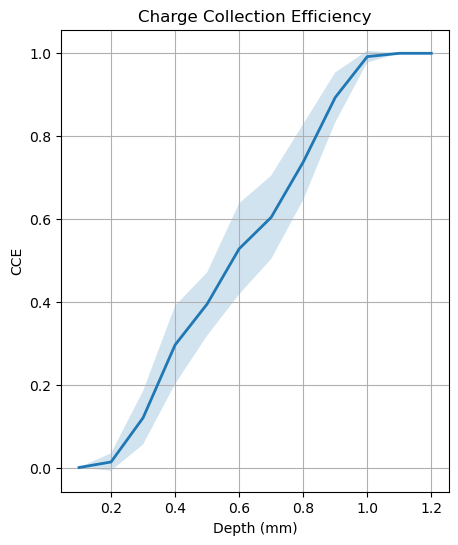

In [31]:
# ============================================================
# CCE
# ============================================================
CCE = N_matrix / N_charges

CCE_mean = np.mean(CCE, axis=1)
CCE_std = np.std(CCE, axis=1)

plt.figure(figsize=(5, 6))

plt.plot(x_pos * 10, CCE_mean, linewidth=2)
plt.fill_between(x_pos * 10,
                 CCE_mean - CCE_std,
                 CCE_mean + CCE_std,
                 alpha=0.2)

plt.xlabel("Depth (mm)")
plt.ylabel("CCE")
plt.title("Charge Collection Efficiency")
plt.grid()
plt.savefig(f"plot/tau(x)_alpha_{alpha_global}.png", dpi = 300)
plt.show()

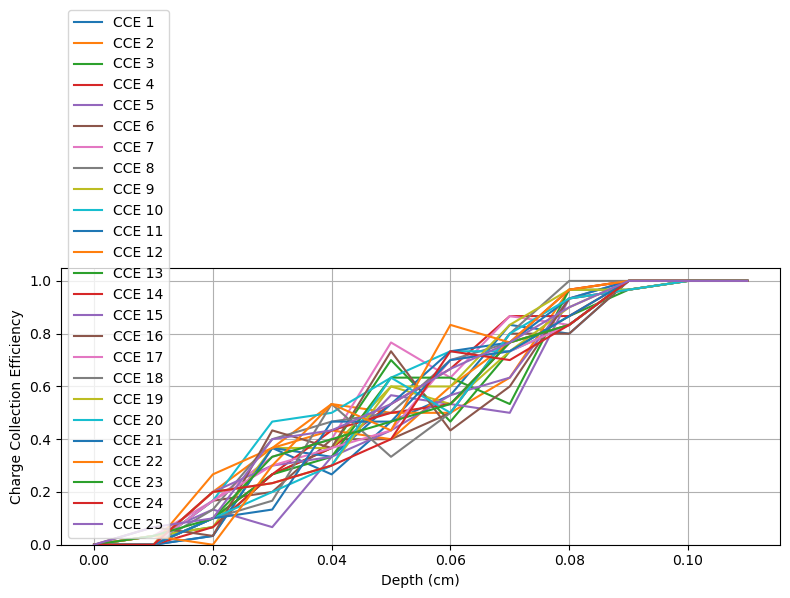

In [32]:
# asse profondità
depth = np.arange(CCE.shape[0]) * step   # oppure il tuo passo in cm

plt.figure(figsize=(8,5))

for i in range(CCE.shape[1]):
    plt.plot(depth, CCE[:, i], label=f"CCE {i+1}")

plt.xlabel("Depth (cm)")
plt.ylabel("Charge Collection Efficiency")
plt.ylim(0,1.05)
plt.grid(True)
plt.legend()
plt.tight_layout()

plt.show()


/tmp/ipykernel_1647990/2204295954.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_rhm_star = get_cmap("inferno")(np.linspace(0.2, 0.8, N))


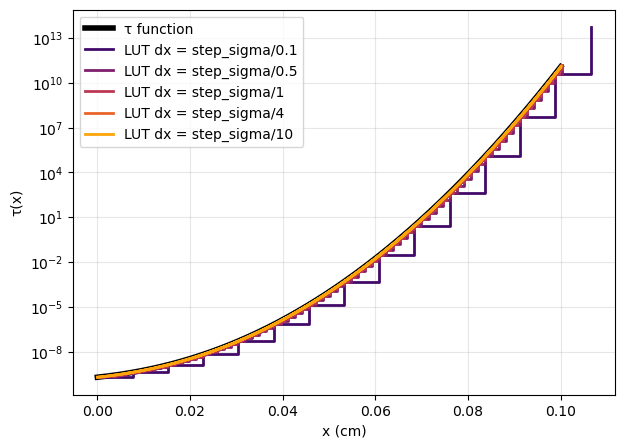

100%|██████████| 510/510 [05:12<00:00, 11.44s/it]

In [15]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.special import erfc
from matplotlib.cm import get_cmap

# ============================================================
# funzione continua
# ============================================================
def tau_exact(x):
    Nd = Ns * erfc(x / (2 * np.sqrt(D_Li * t_ann)))
    if alpha_global == 0:
        return np.inf
    return pref_tau / (alpha_global * Nd)

# ============================================================
# curva continua
# ============================================================
x_fine = np.linspace(0, FCCD_cm, 2000)
tau_cont = np.array([tau_exact(x) for x in x_fine])

# ============================================================
# fattori LUT
# ============================================================
factors = [0.1, 0.5, 1, 4, 10]
N = len(factors)

colors_rhm_star = get_cmap("inferno")(np.linspace(0.2, 0.8, N))

plt.figure(figsize=(7,5))

# continuo (riferimento)
plt.plot(
    x_fine,
    tau_cont,
    color="black",
    linewidth=4,
    label="τ function"
)

# ============================================================
# LUT per ogni fattore
# ============================================================
for i, f in enumerate(factors):

    LUT_dx_local = step_sigma / f
    x_lut_local = np.arange(0, FCCD_cm + LUT_dx_local, LUT_dx_local)

    tau_lut_local = np.array([tau_exact(x) for x in x_lut_local])

    plt.step(
        x_lut_local,
        tau_lut_local,
        where="post",
        color=colors_rhm_star[i],
        linewidth=2,
        label=f"LUT dx = step_sigma/{f}"
    )

# ============================================================
# grafico
# ============================================================
plt.yscale("log")
plt.xlabel("x (cm)")
plt.ylabel("τ(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()